## **Connect Colab**

In [2]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [4]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 12 file(s) under /src/
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py
src/utils/save.py -> /content/src/utils/save.py

 All files saved under /content/src/
Contents of /content/src/:
/content/src/cl_strategies/naive.py
/content/src/cl_strategies/reharsa

## **Download DATASET**

In [5]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh    # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

100% 6.53G/6.53G [06:57<00:00, 16.8MB/s]  
Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4

Detecting path and updating config.py...
Found in kagglehub cache: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
DATASET_ROOT = '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/'
OUTPUT_ROOT  = '/content/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [6]:
# imports
%run /content/src/imports.py

Using device: cuda


In [7]:
# BASE
cfg.OUTPUT_ROOT = "./UCF101/processed_data_base"
preprocess_dataset(splits=["test"])


--- Preprocessing UCF101 ---
From: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
To  : ./UCF101/processed_data_base
Classes: 5 | Limit: Full

Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_base


In [8]:

# TASK 1
cfg.SELECTED_CLASSES = cfg.TASK_1
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task1"
preprocess_dataset(splits=["train", "val", "test"])

# TASK 2
#cfg.SELECTED_CLASSES = cfg.TASK_2
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task2"
#preprocess_dataset(splits=["train", "val", "test"])

# TASK 3
#cfg.SELECTED_CLASSES = cfg.TASK_3
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task3"
#preprocess_dataset(splits=["train", "val", "test"])

# TASK 4
#cfg.SELECTED_CLASSES = cfg.TASK_4
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task4"
#preprocess_dataset(splits=["train", "val", "test"])


--- Preprocessing UCF101 ---
From: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
To  : ./UCF101/processed_data_task1
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task1


In [12]:
BASE_CLASSES  = list(cfg.SELECTED_CLASSES)
TASK1_CLASSES = list(cfg.TASK_1)

ALL_CLASSES_LIST = BASE_CLASSES + TASK1_CLASSES

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"Base classes   ({len(BASE_CLASSES)}): {BASE_CLASSES}")
print(f"Task 1 classes ({len(TASK1_CLASSES)}): {TASK1_CLASSES}")
print(f"Total classes  ({len(ALL_CLASSES_LIST)}): {ALL_CLASSES_LIST}")
print(f"\nclass_to_idx:\n{class_to_idx}")

Base classes   (5): ['JumpingJack', 'PlayingTabla', 'PoleVault', 'PommelHorse', 'PushUps']
Task 1 classes (3): ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery']
Total classes  (8): ['JumpingJack', 'PlayingTabla', 'PoleVault', 'PommelHorse', 'PushUps', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery']

class_to_idx:
{'JumpingJack': 0, 'PlayingTabla': 1, 'PoleVault': 2, 'PommelHorse': 3, 'PushUps': 4, 'ApplyEyeMakeup': 5, 'ApplyLipstick': 6, 'Archery': 7}


In [14]:
base_test        = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"), class_to_idx=class_to_idx)
base_test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

base_test   : 78 clips
task1_train : 301 clips
task1_val   : 50 clips
task1_test  : 53 clips
combined    : 131 clips

Base  label range : 0 -> 4  (expected 0–4)
Task1 label range : 5 -> 7  (expected 5–7)
Unique base labels  : [0, 1, 2, 3, 4]
Unique task1 labels : [5, 6, 7]


In [18]:
 model_base = ResNet50LSTM(num_classes = len(BASE_CLASSES)).to(device)
state      = torch.load(cfg.RESNET50_PATH, map_location=device)
model_base.load_state_dict(state)
model_base = unfreeze_all(model_base)

In [20]:
results_baseline = evaluate_all_tasks(
    model            = model_base,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.0000  Loss=5.7997
  task1_only       -> Acc=0.2075  Loss=2.3787
  combined_t1      -> Acc=0.0840  Loss=4.4156


In [23]:
# new_num_classes=len(ALL_CLASSES_LIST)
model_task1 = expand_classifier(model_base, new_num_classes=12)
model_task1 = unfreeze_all(model_task1).to(device)

In [24]:
print(f"model_task1 FC: in={model_task1.fc.in_features}  out={model_task1.fc.out_features}")

model_task1 FC: in=256  out=12


In [26]:
train_task1 = train_model(
    model        = model_task1,
    train_loader = task1_train_loader,
    val_loader   = task1_val_loader,
)

Epoch [1/1] | Train Acc: 0.7807 Loss: 0.6709 | Val Acc: 0.9600 Loss: 0.1316


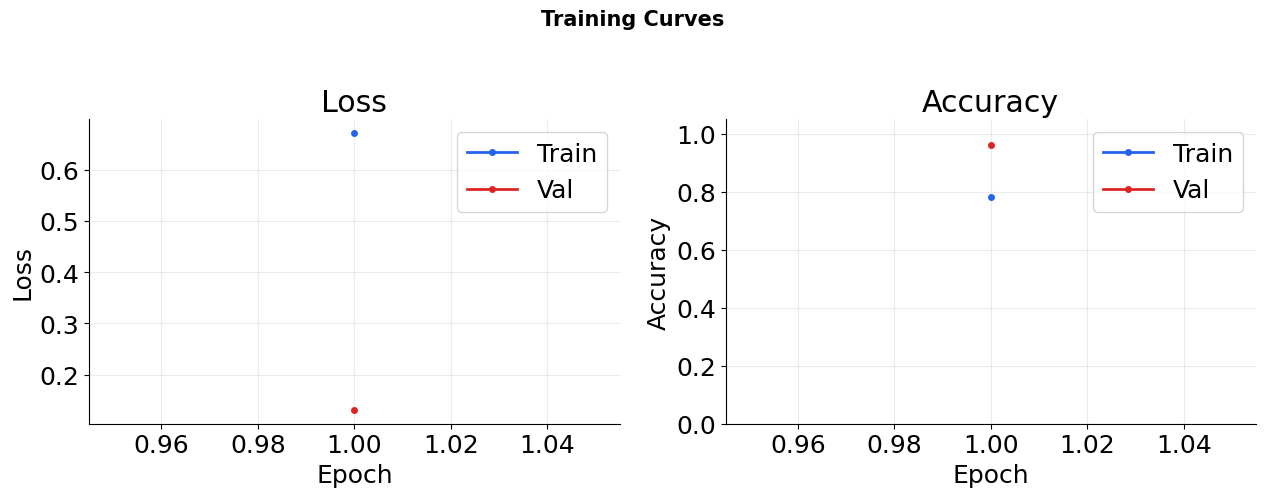

In [28]:
plot_training_results(train_task1)

In [29]:
results_after_t1 = evaluate_all_tasks(
    model   = model_task1,
    device  = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)


  base             -> Acc=0.0000  Loss=4.9155
  task1_only       -> Acc=0.9623  Loss=0.1073
  combined_t1      -> Acc=0.3893  Loss=2.9702


Running Inference on Test Set...


Test Accuracy: 0.3893


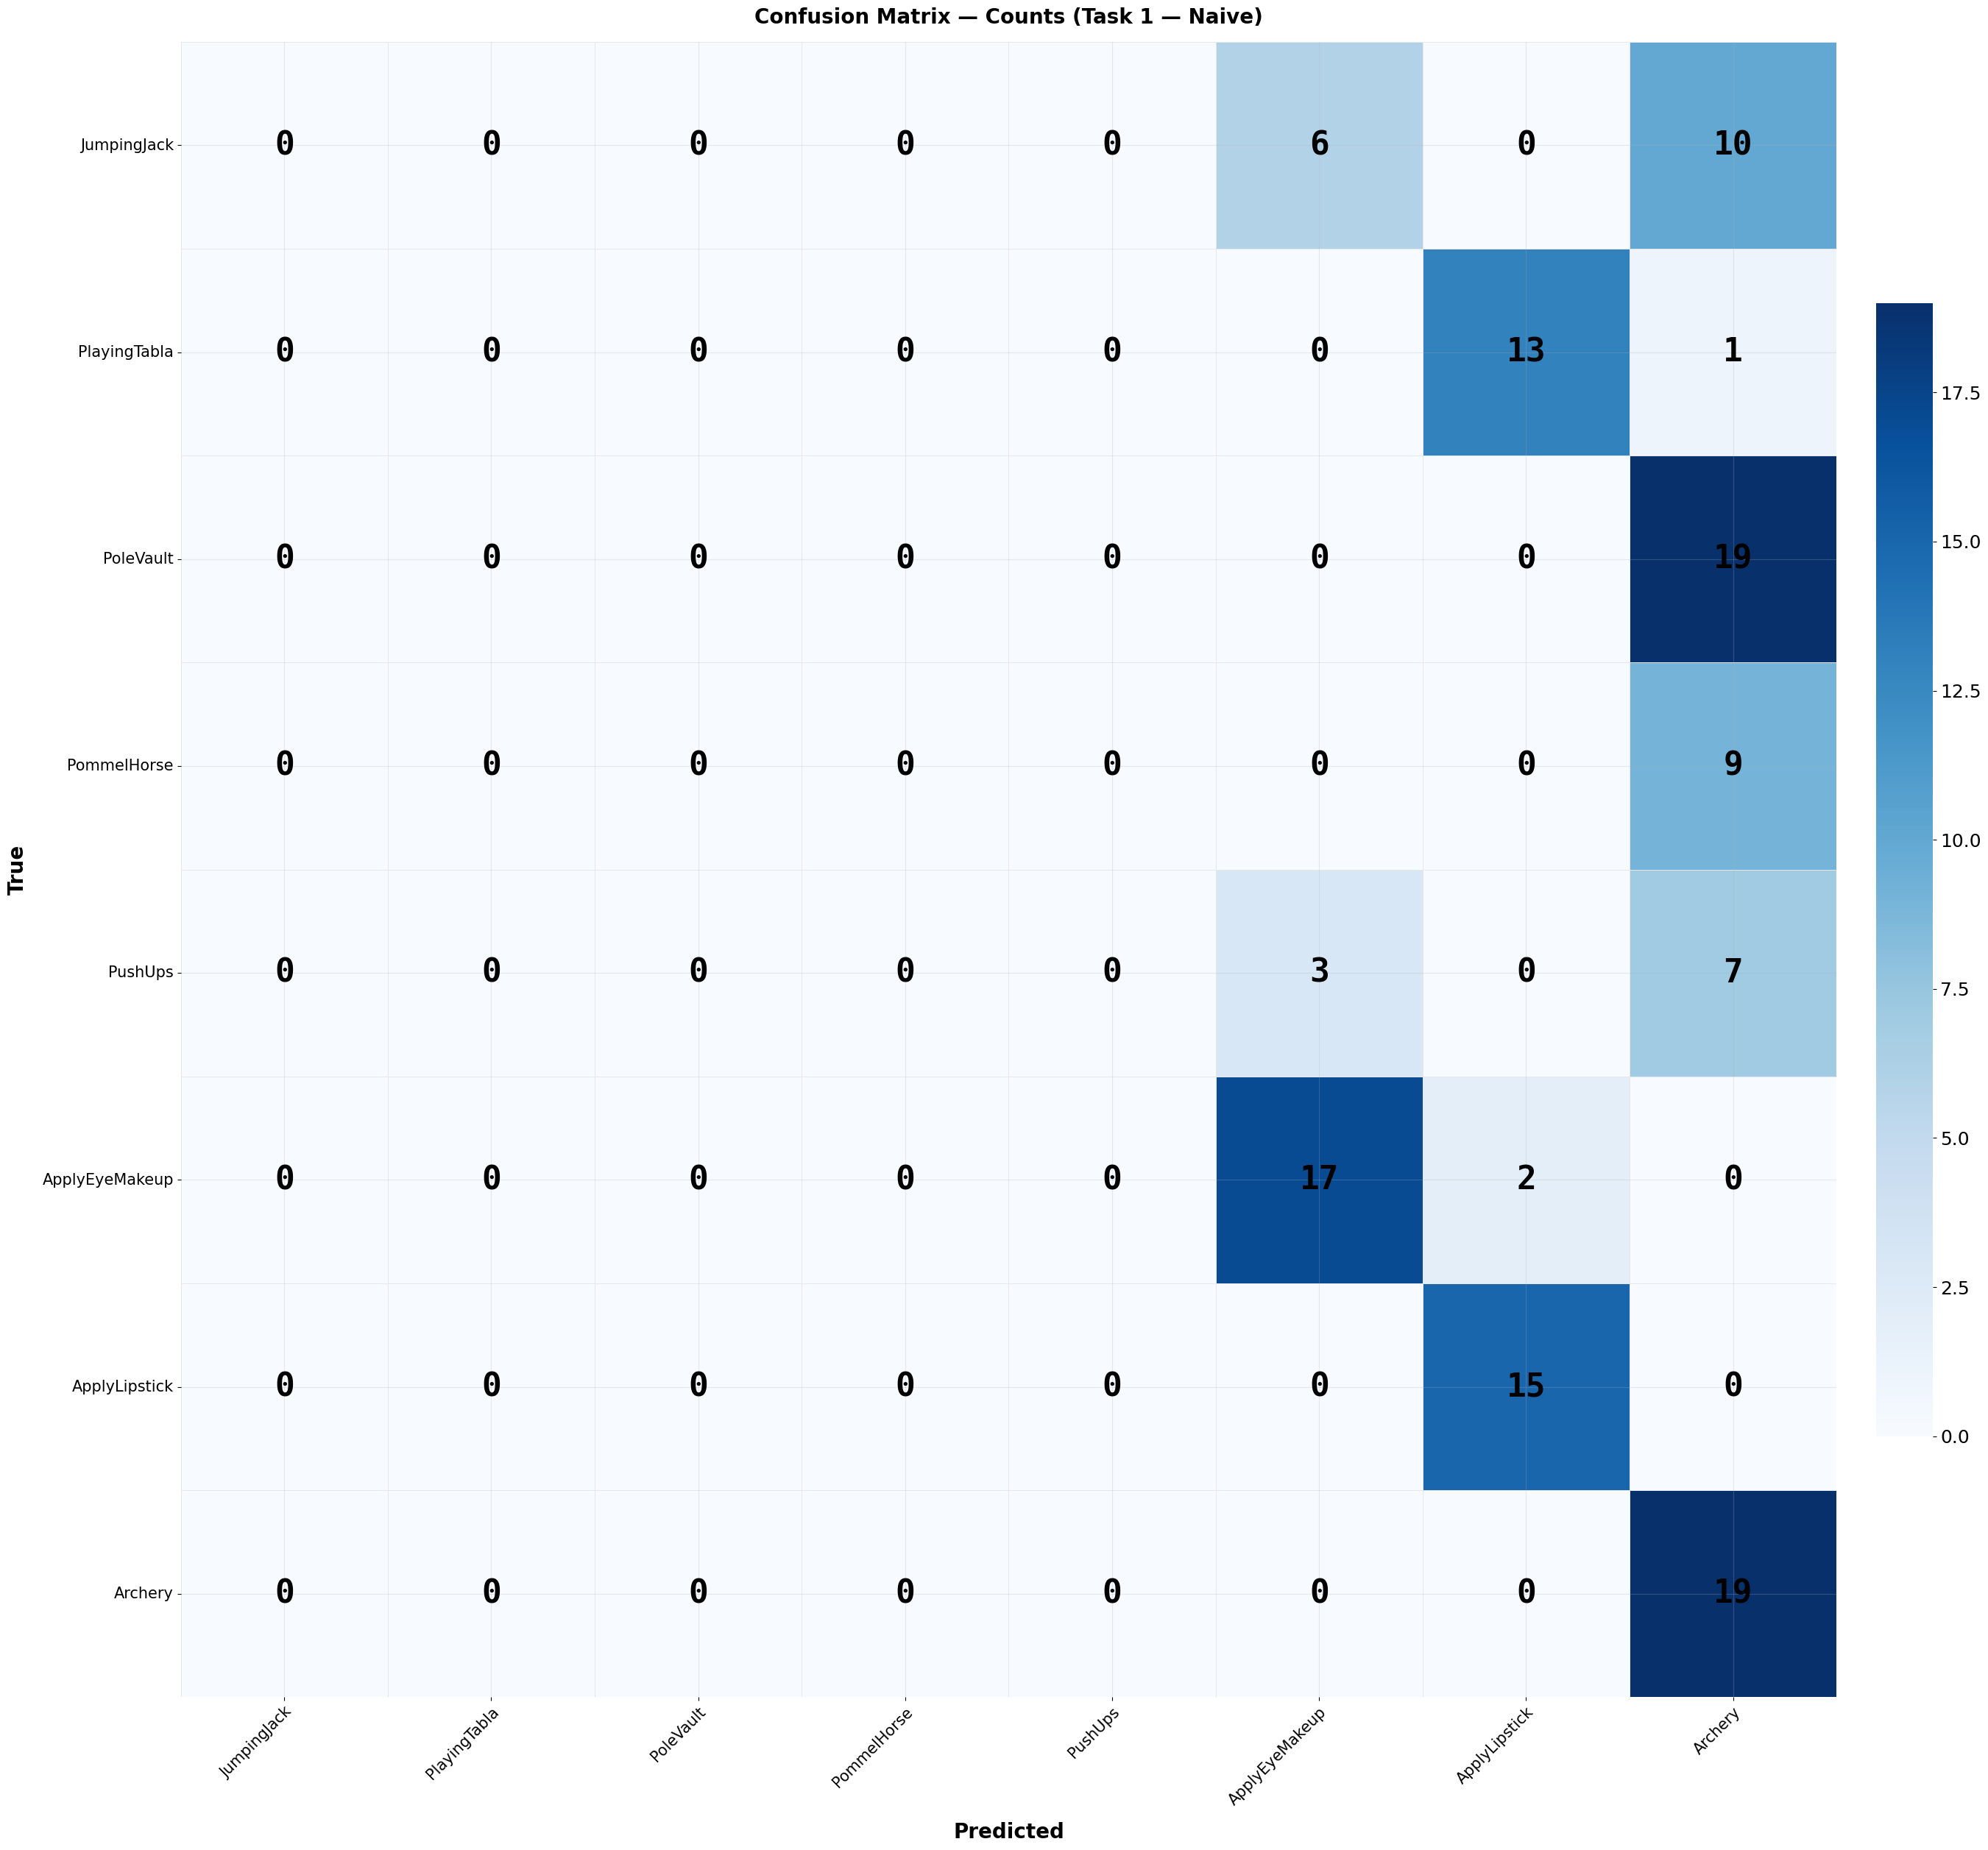

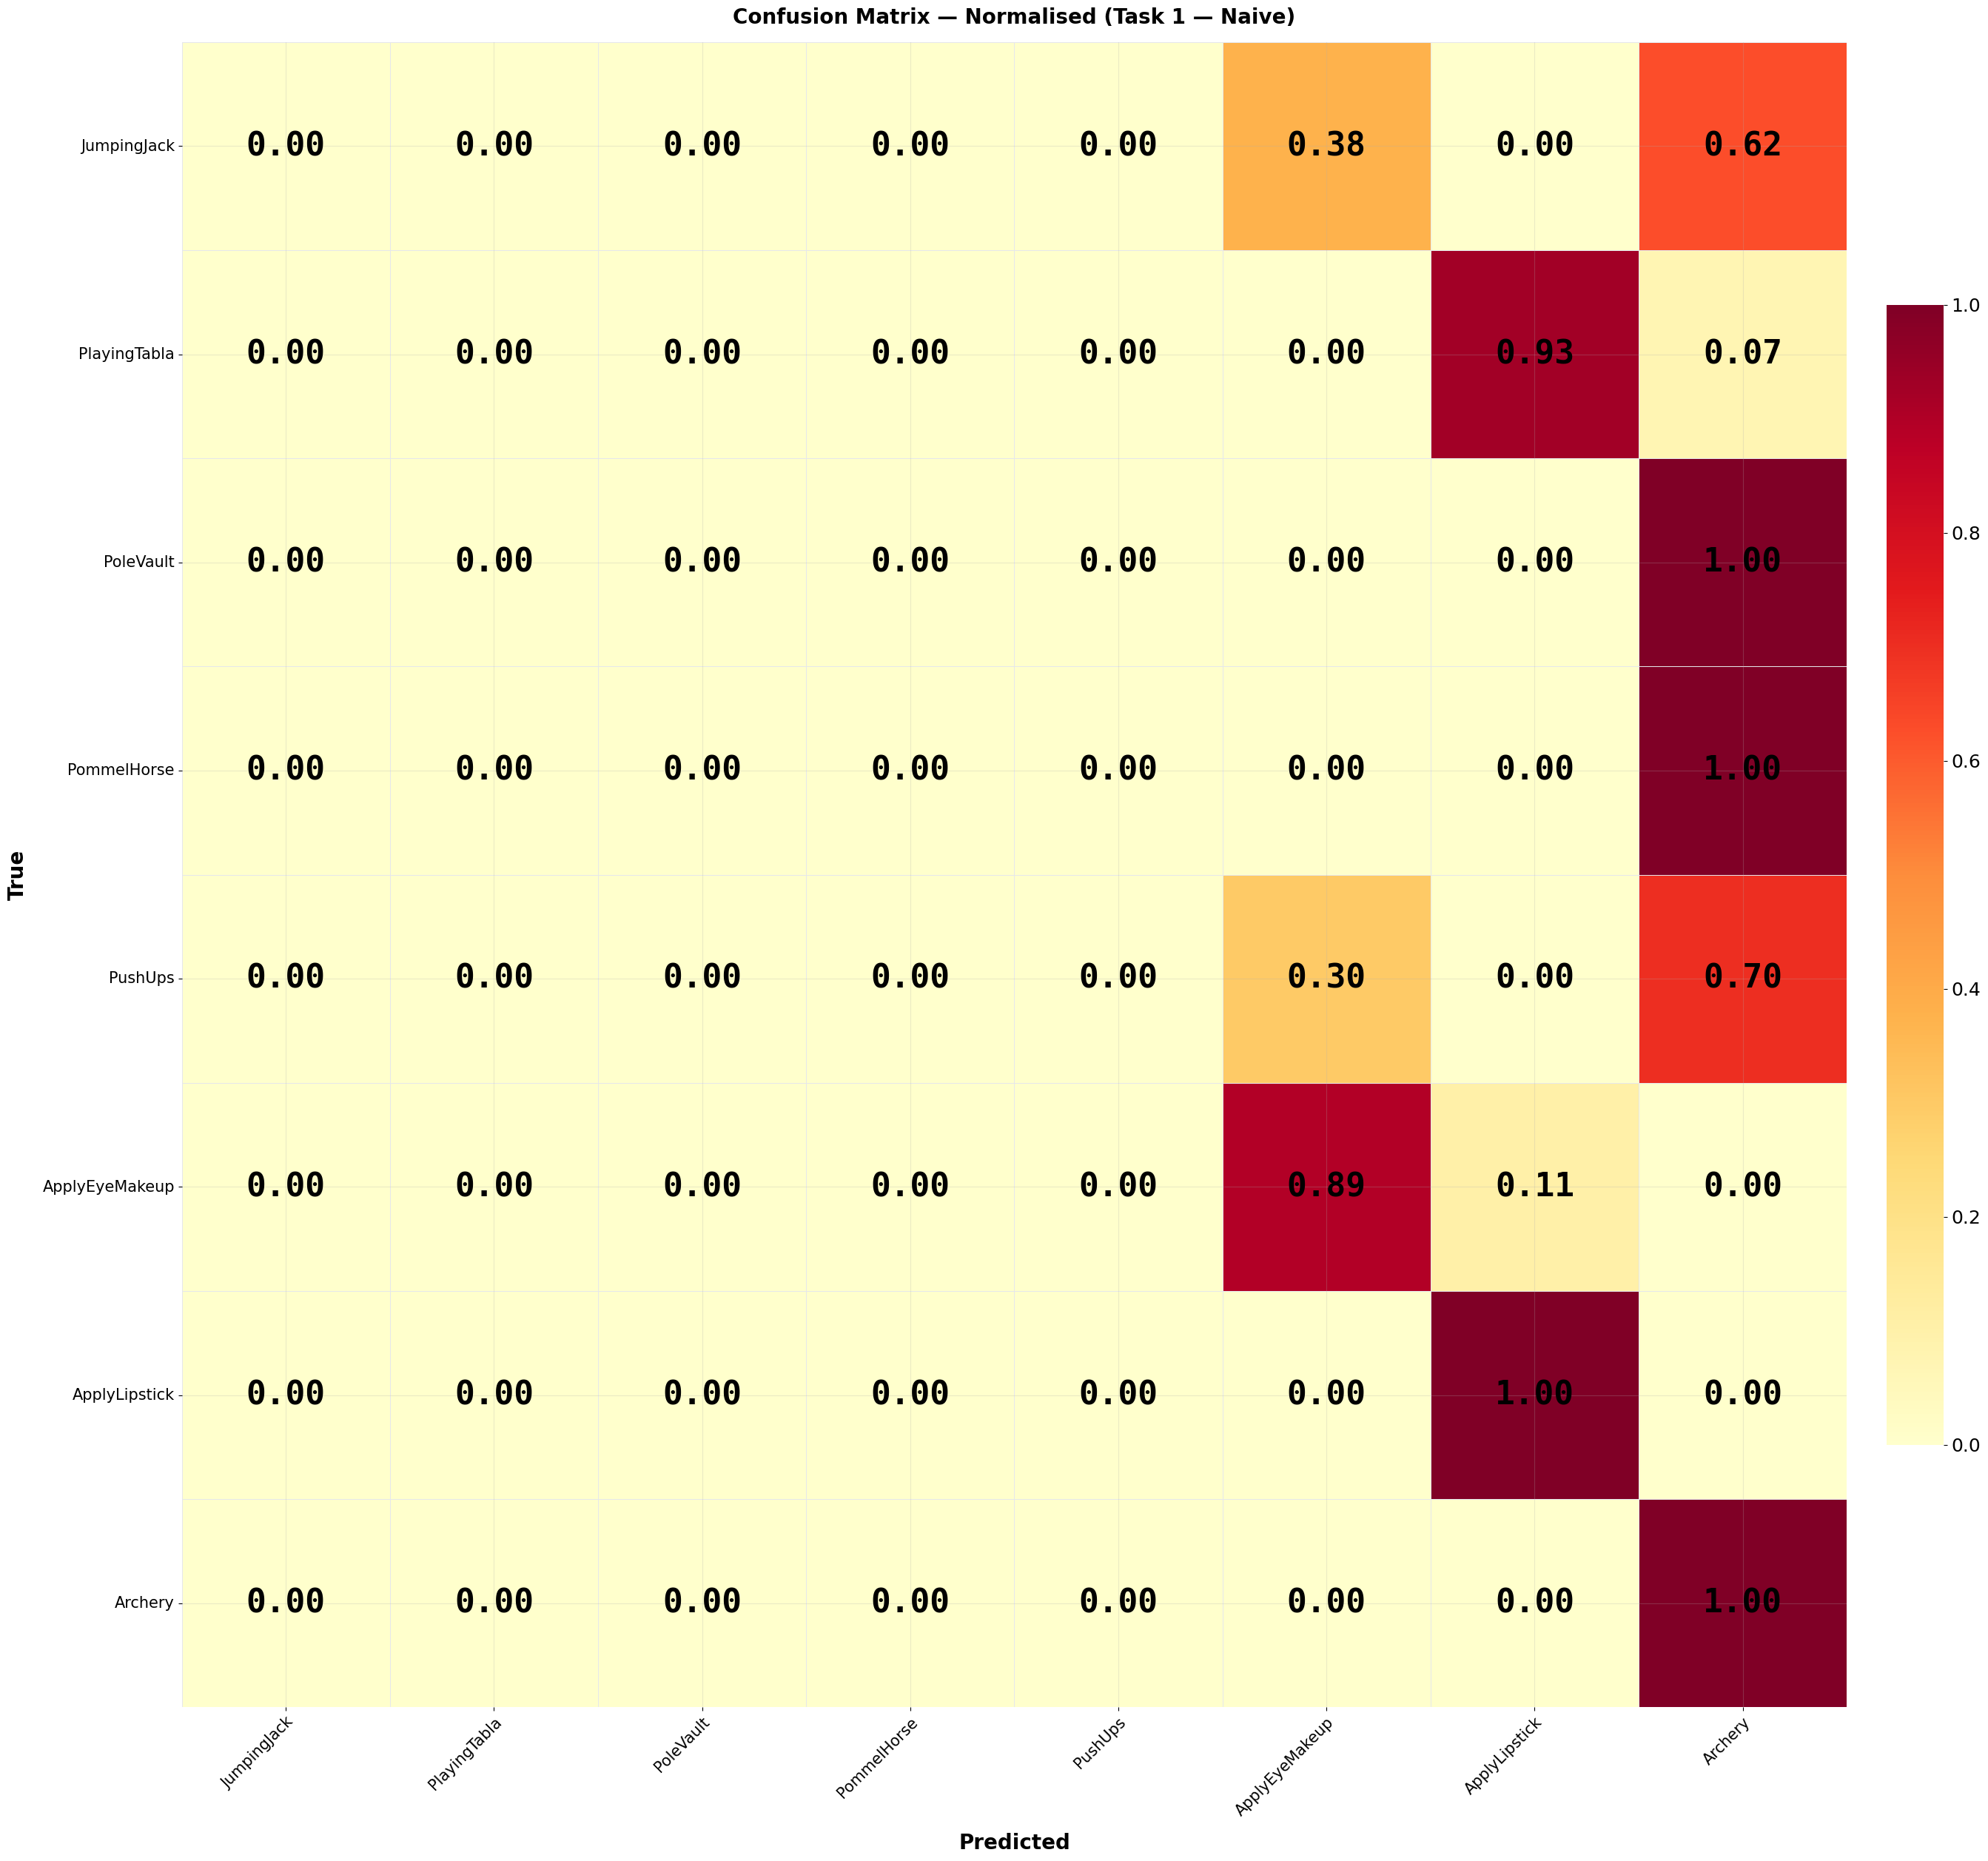

In [30]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = "Task 1 — Naive",
)

In [31]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),               # base: 0–9
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),  # task1: 10–14
)


METRICS FOR 8 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.3893
  Precision : 0.1945
  Recall    : 0.3893
  F1-Score  : 0.2515

PER-CLASS REPORT 
                precision    recall  f1-score   support

   JumpingJack       0.00      0.00      0.00        16
  PlayingTabla       0.00      0.00      0.00        14
     PoleVault       0.00      0.00      0.00        19
   PommelHorse       0.00      0.00      0.00        16
       PushUps       0.00      0.00      0.00        13
ApplyEyeMakeup       0.65      0.89      0.76        19
 ApplyLipstick       0.50      1.00      0.67        15
       Archery       0.29      1.00      0.45        19

     micro avg       0.42      0.39      0.40       131
     macro avg       0.18      0.36      0.23       131
  weighted avg       0.19      0.39      0.25       131

OLD CLASSES [0–4]  (5 classes)
  Accuracy  : 0.0000
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000

              precision    recall  f1-score   support

 